# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Capstone — Search Intelligence Research

## Full-Warehouse Content Decline Prioritization

This capstone investigates whether observable content and SEO performance signals can be used to prioritize pages for earlier human review when they show evidence of declining search performance.

The analysis uses the full pseudonymized FlyRank internship warehouse release and follows a reproducible feature-engineering, modeling, validation, and recommendation workflow.

The objective is decision support: produce a ranked queue that helps content teams decide which pages deserve attention first. The analysis does not attempt to automate content decisions, establish causation, or claim that the observed relationships guarantee future performance.

In [ ]:
from huggingface_hub import login
import getpass

HF_TOKEN = getpass.getpass("Enter your Hugging Face READ token (hf_...): ")
login(token=HF_TOKEN)

print("Hugging Face authentication completed.")

Enter your Hugging Face READ token (hf_...): ··········
Hugging Face authentication completed.


In [ ]:
print("\nTesting warehouse access...")

for name in TABLES:
    try:
        con.execute(
            f"SELECT 1 FROM {name} LIMIT 1"
        ).fetchone()

        print(f"{name:20s} OK")

    except Exception as e:
        print(f"{name:20s} ERROR")
        print(e)


Testing warehouse access...
dim_clients          OK
dim_content          OK
fact_daily           OK
fact_daily_sample    OK
fact_query_90d       OK


In [ ]:
print("\nTesting warehouse access...")

for name in TABLES:
    try:
        con.execute(
            f"SELECT 1 FROM {name} LIMIT 1"
        ).fetchone()

        print(f"{name:20s} OK")

    except Exception as e:
        print(f"{name:20s} ERROR")
        print(e)


Testing warehouse access...
dim_clients          OK
dim_content          OK
fact_daily           OK
fact_daily_sample    OK
fact_query_90d       OK


## Warehouse schema and available signals

Before constructing the final feature table, the analysis inspects the available fields in the warehouse. This prevents assumptions about column availability and ensures that every feature used by the final model is grounded in an actual field from the release.

In [ ]:
# Inspect the schemas of the tables relevant to the Capstone.

for table_name in ["dim_content", "fact_daily", "fact_query_90d"]:
    print("\n" + "=" * 80)
    print(f"{table_name}")
    print("=" * 80)

    schema = con.sql(
        f"DESCRIBE SELECT * FROM {TABLES[table_name]}"
    ).df()

    display(schema)


dim_content


,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,keyword_hash_id,VARCHAR,YES,None,None,None
3,url_hash_id,VARCHAR,YES,None,None,None
4,keyword_char_count,BIGINT,YES,None,None,None
5,keyword_token_count,BIGINT,YES,None,None,None
6,url_char_count,BIGINT,YES,None,None,None
7,content_created_date,DATE,YES,None,None,None
8,content_updated_date,DATE,YES,None,None,None
9,content_type,VARCHAR,YES,None,None,None



fact_daily


,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None



fact_query_90d


,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,query_hash_id,VARCHAR,YES,None,None,None
3,query_char_count,BIGINT,YES,None,None,None
4,query_token_count,BIGINT,YES,None,None,None
5,window_start,DATE,YES,None,None,None
6,window_end,DATE,YES,None,None,None
7,impressions_90d,BIGINT,YES,None,None,None
8,clicks_90d,BIGINT,YES,None,None,None
9,impressions_last30,BIGINT,YES,None,None,None


In [ ]:
# Look at a small number of records from each table.
# This is only schema/structure inspection; we are not loading the full tables.

for table_name in ["dim_content", "fact_daily", "fact_query_90d"]:
    print("\n" + "=" * 80)
    print(f"{table_name} — sample rows")
    print("=" * 80)

    sample = con.sql(
        f"SELECT * FROM {TABLES[table_name]} LIMIT 5"
    ).df()

    display(sample)


dim_content — sample rows


,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,search_volume,competition,competition_level,cpc,main_intent,backlinks,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,30,0.91,HIGH,0.98,transactional,16,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682,2555,NaT,NaT,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,keyword_4329d7aede8e208b,url_3a66d2f2e36823ca,31,6,95,2026-06-12,2026-07-01,keyword article,10,0.00,LOW,0.00,commercial,0,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15438,2430,NaT,NaT,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,keyword_9b08047d3d2a0406,url_809eda7a7e20b3b2,22,5,82,2026-05-09,2026-07-01,keyword article,480,0.36,MEDIUM,0.62,informational,169,4,2026-05-06,gemini-generate-content,gemini-3-flash-preview,16576,2645,NaT,NaT,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,keyword_e7cec7ab1804c1c2,url_5fb42bafc4399861,14,3,92,2026-06-15,2026-06-15,keyword article,0,0.00,LOW,0.00,transactional,0,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15457,2522,NaT,NaT,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,keyword_56b0062a1d8b7524,url_ece0abc3e5fb75f9,24,6,98,2026-05-21,2026-06-01,keyword article,2400,0.70,HIGH,0.90,transactional,52,4,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15776,2552,NaT,NaT,True,False



fact_daily — sample rows


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,sessions_organic,sessions_direct,sessions_referral,sessions_social,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,3.833333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,71.600000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,34.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,23.333333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,17.800000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01



fact_query_90d — sample rows


,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,clicks_last30,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,0,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_922b8eca2a24cd34,34,7,2026-04-02,2026-06-30,13,0,0,0,1,0,1.769231,NaN,11.000000,1466,14,32,0.043656,0.725102
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_9f0c36a6ae2a6a99,16,2,2026-04-02,2026-06-30,16,0,11,0,5,0,23.562500,24.272727,22.000000,1466,14,32,0.043656,0.725102
3,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_a032820b5467e996,24,4,2026-04-02,2026-06-30,55,0,1,0,1,0,2.200000,13.000000,0.000000,1466,14,32,0.043656,0.725102
4,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_ba1a2f131961c5da,18,3,2026-04-02,2026-06-30,14,0,0,0,0,0,3.428571,NaN,NaN,1466,14,32,0.043656,0.725102


## Client history and panel coverage

The warehouse is an unbalanced panel: clients do not necessarily have identical periods of available search data. Before defining the modeling window, client-level coverage is inspected so that the feature and outcome windows are supported by actual observations rather than assumed to be available for every client.

In [ ]:
client_history = con.sql(
    f"""
    SELECT
        client_hash_id,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date,
        COUNT(DISTINCT report_date) AS observed_days
    FROM {TABLES['fact_daily']}
    GROUP BY client_hash_id
    ORDER BY first_date
    """
).df()

print(f"Clients represented in fact_daily: {len(client_history):,}")
display(client_history)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Clients represented in fact_daily: 70


,client_hash_id,first_date,last_date,observed_days
0,client_ff644d8251367cbb,2025-01-27,2026-06-30,514
1,client_9958f0a7ae1df715,2025-01-27,2026-06-30,520
2,client_73cda7b4e4f265ea,2025-02-11,2026-06-30,505
3,client_fef1a8f436438636,2025-03-11,2026-06-30,477
4,client_62f4a7e64f5e0096,2025-06-07,2026-06-30,389
5,client_b10cb2997d0c7c86,2025-06-18,2026-06-30,378
6,client_65de48885f4ef01b,2025-06-21,2026-06-30,375
7,client_c182d11e4862a37d,2025-06-21,2026-06-30,375
8,client_3197e6291363b4db,2025-06-29,2026-06-30,367
9,client_625b6439094e23e4,2025-07-01,2026-06-30,252


## Monthly warehouse coverage

The monthly distribution is checked before selecting the Capstone observation and outcome windows. This confirms where sufficient historical data exists and helps avoid choosing a window that is supported by only a small portion of the panel.

In [ ]:
monthly_coverage = con.sql(
    f"""
    SELECT
        month,
        COUNT(*) AS rows,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS content_items,
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date
    FROM {TABLES['fact_daily']}
    GROUP BY month
    ORDER BY month
    """
).df()

display(monthly_coverage)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,rows,clients,content_items,min_date,max_date
0,2025-01,1297,2,476,2025-01-27,2025-01-31
1,2025-02,75985,3,5903,2025-02-01,2025-02-28
2,2025-03,167859,4,10374,2025-03-01,2025-03-31
3,2025-04,285114,4,13046,2025-04-01,2025-04-30
4,2025-05,349923,4,14887,2025-05-01,2025-05-31
5,2025-06,329201,9,16399,2025-06-01,2025-06-30
6,2025-07,469794,16,27945,2025-07-01,2025-07-31
7,2025-08,704962,15,37204,2025-08-01,2025-08-31
8,2025-09,845813,23,53127,2025-09-01,2025-09-30
9,2025-10,2165471,31,110339,2025-10-01,2025-10-31


## Search Console availability

Because the Capstone focuses on search-performance decline, the analysis verifies the availability of Search Console data before defining the usable modeling population. Rows without available GSC data should not silently be treated as zero search performance.

In [ ]:
gsc_availability = con.sql(
    f"""
    SELECT
        month,
        COUNT(*) AS total_rows,
        COUNT(*) FILTER (
            WHERE gsc_data_available IS TRUE
        ) AS gsc_available_rows,
        COUNT(*) FILTER (
            WHERE gsc_data_available IS FALSE
        ) AS gsc_unavailable_rows
    FROM {TABLES['fact_daily']}
    GROUP BY month
    ORDER BY month
    """
).df()

gsc_availability["gsc_available_pct"] = (
    gsc_availability["gsc_available_rows"]
    / gsc_availability["total_rows"]
    * 100
)

display(gsc_availability)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,total_rows,gsc_available_rows,gsc_unavailable_rows,gsc_available_pct
0,2025-01,1297,1297,0,100.000000
1,2025-02,75985,75985,0,100.000000
2,2025-03,167859,167859,0,100.000000
3,2025-04,285114,285114,0,100.000000
4,2025-05,349923,349923,0,100.000000
5,2025-06,329201,329201,0,100.000000
6,2025-07,469794,469794,0,100.000000
7,2025-08,704962,704962,0,100.000000
8,2025-09,845813,845813,0,100.000000
9,2025-10,2165471,1187654,977817,54.845066


In [ ]:
# Content-level history and GSC availability audit

content_history = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date,
        COUNT(*) AS observed_rows,

        SUM(
            CASE
                WHEN gsc_data_available THEN 1
                ELSE 0
            END
        ) AS gsc_available_days,

        SUM(
            CASE
                WHEN NOT gsc_data_available THEN 1
                ELSE 0
            END
        ) AS gsc_unavailable_days,

        SUM(
            CASE
                WHEN gsc_data_available
                     AND gsc_impressions IS NOT NULL
                THEN gsc_impressions
                ELSE 0
            END
        ) AS total_gsc_impressions,

        SUM(
            CASE
                WHEN gsc_data_available
                     AND gsc_clicks IS NOT NULL
                THEN gsc_clicks
                ELSE 0
            END
        ) AS total_gsc_clicks

    FROM {TABLES['fact_daily']}

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print(f"Content-client histories: {len(content_history):,}")

print("\nHistory length distribution:")
print(
    content_history["observed_rows"]
    .describe()
    .to_string()
)

print("\nGSC availability:")
content_history["gsc_available_pct"] = (
    content_history["gsc_available_days"]
    / content_history["observed_rows"]
    * 100
)

print(
    content_history["gsc_available_pct"]
    .describe()
    .to_string()
)

print("\nFirst 10 rows:")
display(content_history.head(10))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content-client histories: 427,292

History length distribution:
count    427292.000000
mean        184.500658
std          93.721777
min           3.000000
25%         112.000000
50%         218.000000
75%         240.000000
max         520.000000

GSC availability:
count    427292.000000
mean         34.589617
std          38.539889
min           0.000000
25%           0.000000
50%          12.987013
75%          75.968992
max         100.000000

First 10 rows:


,client_hash_id,content_hash_id,first_date,last_date,observed_rows,gsc_available_days,gsc_unavailable_days,total_gsc_impressions,total_gsc_clicks,gsc_available_pct
0,client_9958f0a7ae1df715,content_199a7503ef4984b6,2025-02-04,2026-06-30,511,468.0,43.0,14328.0,70.0,91.585127
1,client_9958f0a7ae1df715,content_cd7680fa9ecf0f29,2025-02-04,2026-06-30,512,460.0,52.0,5845.0,5.0,89.843750
2,client_9958f0a7ae1df715,content_a1de860c6349747e,2025-02-04,2026-06-30,512,470.0,42.0,4787.0,19.0,91.796875
3,client_9958f0a7ae1df715,content_cd36f906cac66324,2025-02-06,2026-06-30,510,508.0,2.0,11963.0,29.0,99.607843
4,client_9958f0a7ae1df715,content_28de1fb24f0fb4a8,2025-02-03,2026-06-30,513,507.0,6.0,19741.0,34.0,98.830409
5,client_9958f0a7ae1df715,content_98e997bcdf93db50,2025-02-06,2026-06-30,510,454.0,56.0,6440.0,3.0,89.019608
6,client_9958f0a7ae1df715,content_6afb4ede795f9338,2025-02-07,2026-06-30,509,508.0,1.0,12548.0,12.0,99.803536
7,client_9958f0a7ae1df715,content_12415a5ac1570217,2025-02-04,2026-06-30,512,482.0,30.0,22379.0,143.0,94.140625
8,client_9958f0a7ae1df715,content_160adf69243b631f,2025-02-04,2026-06-30,512,446.0,66.0,5859.0,3.0,87.109375
9,client_9958f0a7ae1df715,content_875ebebd0b4b106d,2025-02-07,2026-06-30,509,492.0,17.0,37043.0,436.0,96.660118


In [ ]:
# GSC availability by client

client_gsc_availability = con.sql(f"""
    SELECT
        client_hash_id,

        COUNT(*) AS total_rows,

        SUM(
            CASE
                WHEN gsc_data_available THEN 1
                ELSE 0
            END
        ) AS gsc_available_rows,

        ROUND(
            100.0 * SUM(
                CASE
                    WHEN gsc_data_available THEN 1
                    ELSE 0
                END
            ) / COUNT(*),
            2
        ) AS gsc_available_pct,

        MIN(
            CASE
                WHEN gsc_data_available THEN report_date
            END
        ) AS first_gsc_available_date,

        MAX(
            CASE
                WHEN gsc_data_available THEN report_date
            END
        ) AS last_gsc_available_date

    FROM {TABLES['fact_daily']}

    GROUP BY client_hash_id

    ORDER BY gsc_available_pct DESC
""").df()

print(f"Clients analyzed: {len(client_gsc_availability):,}")

display(client_gsc_availability)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Clients analyzed: 70


,client_hash_id,total_rows,gsc_available_rows,gsc_available_pct,first_gsc_available_date,last_gsc_available_date
0,client_e5c2aa26a8598242,555095,501795.0,90.40,2026-02-19,2026-06-30
1,client_8ddc46da5414ffd8,285053,248287.0,87.10,2026-04-07,2026-06-30
2,client_9958f0a7ae1df715,1470881,1262452.0,85.83,2025-01-27,2026-06-30
3,client_20259bd6705d81d4,667479,570184.0,85.42,2026-02-19,2026-06-30
4,client_23a62021009f63c4,3251375,2748802.0,84.54,2025-09-24,2026-06-30
5,client_73cda7b4e4f265ea,8708971,7326196.0,84.12,2025-02-11,2026-06-30
6,client_62f4a7e64f5e0096,5676451,4769284.0,84.02,2025-06-07,2026-06-30
7,client_e547b89c05043229,2451879,1954051.0,79.70,2025-11-15,2026-06-30
8,client_06d356715a8ff3b6,96192,74169.0,77.11,2026-04-10,2026-06-30
9,client_86ebc2f12c01f586,195220,149213.0,76.43,2026-03-11,2026-06-30


## 4. Content-Level Performance Analysis

We now aggregate the daily performance data to the content level. The goal is to understand
which content items are generating meaningful organic search and engagement performance,
while keeping the computation inside DuckDB.

In [ ]:
monthly_performance = con.execute("""
    SELECT
        DATE_TRUNC('month', report_date) AS month,
        COUNT(*) AS rows,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS content_items,

        SUM(COALESCE(gsc_impressions, 0)) AS gsc_impressions,
        SUM(COALESCE(gsc_clicks, 0)) AS gsc_clicks,

        SUM(COALESCE(ga4_pageviews, 0)) AS pageviews,
        SUM(COALESCE(ga4_sessions, 0)) AS sessions,

        SUM(COALESCE(sessions_organic, 0)) AS organic_sessions,
        SUM(COALESCE(sessions_ai, 0)) AS ai_sessions

    FROM fact_daily

    GROUP BY 1
    ORDER BY 1
""").df()

monthly_performance

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,rows,clients,content_items,gsc_impressions,gsc_clicks,pageviews,sessions,organic_sessions,ai_sessions
0,2025-01-01,1297,2,476,13853.0,108.0,0.0,0.0,0.0,0.0
1,2025-02-01,75985,3,5903,1195015.0,7823.0,0.0,0.0,0.0,0.0
2,2025-03-01,167859,4,10374,3847103.0,26138.0,0.0,0.0,0.0,0.0
3,2025-04-01,285114,4,13046,8843940.0,52974.0,0.0,0.0,0.0,0.0
4,2025-05-01,349923,4,14887,14454515.0,70374.0,0.0,0.0,0.0,0.0
5,2025-06-01,329201,9,16399,16930659.0,70245.0,0.0,0.0,0.0,0.0
6,2025-07-01,469794,16,27945,20298448.0,84676.0,0.0,0.0,0.0,0.0
7,2025-08-01,704962,15,37204,29289942.0,119373.0,0.0,0.0,0.0,0.0
8,2025-09-01,845813,23,53127,37726329.0,176130.0,0.0,0.0,0.0,0.0
9,2025-10-01,2165471,31,110339,55073098.0,274631.0,35809.0,22210.0,34009.0,422.0


In [ ]:
monthly_rates = con.execute("""
    SELECT
        month,
        rows,
        clients,
        content_items,

        gsc_impressions,
        gsc_clicks,

        CASE
            WHEN gsc_impressions > 0
            THEN gsc_clicks * 100.0 / gsc_impressions
            ELSE NULL
        END AS gsc_ctr_pct,

        pageviews,
        sessions,
        organic_sessions,
        ai_sessions,

        CASE
            WHEN sessions > 0
            THEN organic_sessions * 100.0 / sessions
            ELSE NULL
        END AS organic_session_share_pct,

        CASE
            WHEN sessions > 0
            THEN ai_sessions * 100.0 / sessions
            ELSE NULL
        END AS ai_session_share_pct,

        CASE
            WHEN content_items > 0
            THEN gsc_impressions * 1.0 / content_items
            ELSE NULL
        END AS impressions_per_content

    FROM monthly_performance

    ORDER BY month
""").df()

monthly_rates

,month,rows,clients,content_items,gsc_impressions,gsc_clicks,gsc_ctr_pct,pageviews,sessions,organic_sessions,ai_sessions,organic_session_share_pct,ai_session_share_pct,impressions_per_content
0,2025-01-01,1297,2,476,13853.0,108.0,0.779615,0.0,0.0,0.0,0.0,NaN,NaN,29.102941
1,2025-02-01,75985,3,5903,1195015.0,7823.0,0.654636,0.0,0.0,0.0,0.0,NaN,NaN,202.441979
2,2025-03-01,167859,4,10374,3847103.0,26138.0,0.679420,0.0,0.0,0.0,0.0,NaN,NaN,370.840852
3,2025-04-01,285114,4,13046,8843940.0,52974.0,0.598986,0.0,0.0,0.0,0.0,NaN,NaN,677.904338
4,2025-05-01,349923,4,14887,14454515.0,70374.0,0.486865,0.0,0.0,0.0,0.0,NaN,NaN,970.948814
5,2025-06-01,329201,9,16399,16930659.0,70245.0,0.414898,0.0,0.0,0.0,0.0,NaN,NaN,1032.420209
6,2025-07-01,469794,16,27945,20298448.0,84676.0,0.417155,0.0,0.0,0.0,0.0,NaN,NaN,726.371372
7,2025-08-01,704962,15,37204,29289942.0,119373.0,0.407556,0.0,0.0,0.0,0.0,NaN,NaN,787.279379
8,2025-09-01,845813,23,53127,37726329.0,176130.0,0.466862,0.0,0.0,0.0,0.0,NaN,NaN,710.115930
9,2025-10-01,2165471,31,110339,55073098.0,274631.0,0.498666,35809.0,22210.0,34009.0,422.0,153.124719,1.900045,499.126311


In [ ]:
traffic_check = con.execute("""
    SELECT
        DATE_TRUNC('month', report_date) AS month,

        SUM(COALESCE(ga4_sessions, 0)) AS total_sessions,

        SUM(COALESCE(sessions_organic, 0)) AS organic_sessions,
        SUM(COALESCE(sessions_direct, 0)) AS direct_sessions,
        SUM(COALESCE(sessions_referral, 0)) AS referral_sessions,
        SUM(COALESCE(sessions_social, 0)) AS social_sessions,
        SUM(COALESCE(sessions_paid, 0)) AS paid_sessions,
        SUM(COALESCE(sessions_ai, 0)) AS ai_sessions,

        SUM(
            COALESCE(sessions_organic, 0)
            + COALESCE(sessions_direct, 0)
            + COALESCE(sessions_referral, 0)
            + COALESCE(sessions_social, 0)
            + COALESCE(sessions_paid, 0)
            + COALESCE(sessions_ai, 0)
        ) AS channel_sessions

    FROM fact_daily

    GROUP BY 1
    ORDER BY 1
""").df()

traffic_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,total_sessions,organic_sessions,direct_sessions,referral_sessions,social_sessions,paid_sessions,ai_sessions,channel_sessions
0,2025-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-02-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-03-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-05-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2025-06-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2025-07-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2025-08-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2025-09-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2025-10-01,22210.0,34009.0,1895.0,811.0,60.0,114.0,422.0,37311.0


In [ ]:
traffic_check["difference"] = (
    traffic_check["total_sessions"]
    - traffic_check["channel_sessions"]
)

traffic_check["channel_coverage_pct"] = (
    traffic_check["channel_sessions"]
    / traffic_check["total_sessions"]
    * 100
).where(
    traffic_check["total_sessions"] > 0
)

traffic_check

,month,total_sessions,organic_sessions,direct_sessions,referral_sessions,social_sessions,paid_sessions,ai_sessions,channel_sessions,difference,channel_coverage_pct
0,2025-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,2025-02-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,2025-03-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,2025-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,2025-05-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
5,2025-06-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
6,2025-07-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
7,2025-08-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
8,2025-09-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
9,2025-10-01,22210.0,34009.0,1895.0,811.0,60.0,114.0,422.0,37311.0,-15101.0,167.991896


In [ ]:
print("Traffic / session related columns:")

schema[
    schema["column_name"].str.contains(
        "session|page|view|traffic|organic|ai|click|impression",
        case=False,
        regex=True
    )
]

Traffic / session related columns:


,column_name,column_type,null,key,default,extra
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
11,ga4_pageviews,BIGINT,YES,None,None,None
12,ga4_sessions,BIGINT,YES,None,None,None
14,ga4_engaged_sessions,BIGINT,YES,None,None,None
16,sessions_organic,BIGINT,YES,None,None,None
17,sessions_direct,BIGINT,YES,None,None,None
18,sessions_referral,BIGINT,YES,None,None,None


In [ ]:
print("Building content performance table...")

content_performance = con.execute("""
    SELECT
        fd.client_hash_id,
        fd.content_hash_id,

        MIN(fd.report_date) AS first_date,
        MAX(fd.report_date) AS last_date,

        COUNT(*) AS observed_days,

        -- GSC performance
        SUM(COALESCE(fd.gsc_impressions, 0)) AS total_gsc_impressions,
        SUM(COALESCE(fd.gsc_clicks, 0)) AS total_gsc_clicks,

        -- GA4 performance
        SUM(COALESCE(fd.ga4_pageviews, 0)) AS total_pageviews,
        SUM(COALESCE(fd.ga4_sessions, 0)) AS total_sessions,
        SUM(COALESCE(fd.ga4_users, 0)) AS total_users,
        SUM(COALESCE(fd.ga4_engaged_sessions, 0)) AS total_engaged_sessions,

        -- Traffic channels
        SUM(COALESCE(fd.sessions_organic, 0)) AS total_organic_sessions,
        SUM(COALESCE(fd.sessions_direct, 0)) AS total_direct_sessions,
        SUM(COALESCE(fd.sessions_referral, 0)) AS total_referral_sessions,
        SUM(COALESCE(fd.sessions_social, 0)) AS total_social_sessions,
        SUM(COALESCE(fd.sessions_paid, 0)) AS total_paid_sessions,
        SUM(COALESCE(fd.sessions_ai, 0)) AS total_ai_sessions,

        -- AI sources
        SUM(COALESCE(fd.ai_chatgpt, 0)) AS total_chatgpt_sessions,
        SUM(COALESCE(fd.ai_perplexity, 0)) AS total_perplexity_sessions,
        SUM(COALESCE(fd.ai_gemini, 0)) AS total_gemini_sessions,
        SUM(COALESCE(fd.ai_copilot, 0)) AS total_copilot_sessions,
        SUM(COALESCE(fd.ai_claude, 0)) AS total_claude_sessions,
        SUM(COALESCE(fd.ai_meta, 0)) AS total_meta_sessions,
        SUM(COALESCE(fd.ai_other, 0)) AS total_other_ai_sessions,

        -- Engagement
        SUM(COALESCE(fd.scroll_events, 0)) AS total_scroll_events,

        -- Average search position
        AVG(
            CASE
                WHEN fd.gsc_data_available = TRUE
                THEN fd.gsc_avg_position
                ELSE NULL
            END
        ) AS avg_gsc_position,

        -- Derived GSC CTR
        CASE
            WHEN SUM(COALESCE(fd.gsc_impressions, 0)) > 0
            THEN
                100.0
                * SUM(COALESCE(fd.gsc_clicks, 0))
                / SUM(COALESCE(fd.gsc_impressions, 0))
            ELSE NULL
        END AS gsc_ctr_pct,

        -- Organic share of GA4 sessions
        CASE
            WHEN SUM(COALESCE(fd.ga4_sessions, 0)) > 0
            THEN
                100.0
                * SUM(COALESCE(fd.sessions_organic, 0))
                / SUM(COALESCE(fd.ga4_sessions, 0))
            ELSE NULL
        END AS organic_session_share_pct,

        -- AI share of GA4 sessions
        CASE
            WHEN SUM(COALESCE(fd.ga4_sessions, 0)) > 0
            THEN
                100.0
                * SUM(COALESCE(fd.sessions_ai, 0))
                / SUM(COALESCE(fd.ga4_sessions, 0))
            ELSE NULL
        END AS ai_session_share_pct,

        -- Average daily impressions
        CASE
            WHEN COUNT(*) > 0
            THEN
                1.0 * SUM(COALESCE(fd.gsc_impressions, 0))
                / COUNT(*)
            ELSE NULL
        END AS avg_daily_impressions

    FROM fact_daily fd

    GROUP BY
        fd.client_hash_id,
        fd.content_hash_id

    HAVING COUNT(*) >= 30

    ORDER BY
        total_gsc_impressions DESC
""").fetchdf()

print("Content performance rows:", len(content_performance))

Building content performance table...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content performance rows: 407872


In [ ]:
print("Inspecting rows with channel traffic but zero total sessions...")

zero_session_channels = con.execute("""
    SELECT
        client_hash_id,
        content_hash_id,
        observed_days,

        total_sessions,

        total_organic_sessions,
        total_direct_sessions,
        total_referral_sessions,
        total_social_sessions,
        total_paid_sessions,
        total_ai_sessions,

        total_pageviews,
        total_users,
        total_gsc_impressions,
        total_gsc_clicks

    FROM content_performance

    WHERE total_sessions = 0
      AND (
            total_organic_sessions
          + total_direct_sessions
          + total_referral_sessions
          + total_social_sessions
          + total_paid_sessions
          + total_ai_sessions
          ) > 0

    ORDER BY
        (
            total_organic_sessions
          + total_direct_sessions
          + total_referral_sessions
          + total_social_sessions
          + total_paid_sessions
          + total_ai_sessions
        ) DESC
""").df()

zero_session_channels

Inspecting rows with channel traffic but zero total sessions...


,client_hash_id,content_hash_id,observed_days,total_sessions,total_organic_sessions,total_direct_sessions,total_referral_sessions,total_social_sessions,total_paid_sessions,total_ai_sessions,total_pageviews,total_users,total_gsc_impressions,total_gsc_clicks
0,client_86ebc2f12c01f586,content_7e4514f20010c52d,36,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,369.0,0.0
1,client_f623b01661d4bfe4,content_8a3a09215b01898e,233,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,304.0,0.0
2,client_9c26c096d6e57253,content_9f0457cad4b49b2e,69,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,28.0,0.0


In [ ]:
print("Auditing performance coverage for published-active content...")

published_perf = con.execute("""
    SELECT
        COUNT(*) AS total_published_active,

        SUM(CASE
            WHEN total_gsc_impressions > 0
              OR total_pageviews > 0
              OR total_sessions > 0
            THEN 1 ELSE 0
        END) AS any_performance,

        SUM(CASE
            WHEN total_gsc_impressions > 0
            THEN 1 ELSE 0
        END) AS has_gsc,

        SUM(CASE
            WHEN total_pageviews > 0
            THEN 1 ELSE 0
        END) AS has_pageviews,

        SUM(CASE
            WHEN total_sessions > 0
            THEN 1 ELSE 0
        END) AS has_sessions,

        SUM(CASE
            WHEN total_gsc_impressions = 0
             AND total_pageviews = 0
             AND total_sessions = 0
            THEN 1 ELSE 0
        END) AS no_performance

    FROM content_performance cp
    INNER JOIN dim_content dc
        ON cp.client_hash_id = dc.client_hash_id
       AND cp.content_hash_id = dc.content_hash_id

    WHERE dc.is_published = TRUE
      AND dc.is_deleted = FALSE
""").df()

published_perf

Auditing performance coverage for published-active content...


,total_published_active,any_performance,has_gsc,has_pageviews,has_sessions,no_performance
0,383695,307787.0,284731.0,190195.0,190182.0,75908.0


In [ ]:
print("Auditing observation coverage for measurable published content...")

observation_coverage = con.execute("""
    SELECT
        CASE
            WHEN cp.observed_days < 60 THEN '<60 days'
            WHEN cp.observed_days < 120 THEN '60-119 days'
            WHEN cp.observed_days < 180 THEN '120-179 days'
            WHEN cp.observed_days < 240 THEN '180-239 days'
            ELSE '240+ days'
        END AS observation_bucket,

        COUNT(*) AS content_items,

        SUM(CASE
            WHEN cp.total_gsc_impressions > 0
              OR cp.total_pageviews > 0
              OR cp.total_sessions > 0
            THEN 1 ELSE 0
        END) AS measurable_items,

        ROUND(
            100.0 *
            SUM(CASE
                WHEN cp.total_gsc_impressions > 0
                  OR cp.total_pageviews > 0
                  OR cp.total_sessions > 0
                THEN 1 ELSE 0
            END)
            / COUNT(*),
            2
        ) AS measurable_pct,

        ROUND(AVG(cp.total_gsc_impressions), 2) AS avg_gsc_impressions,

        ROUND(AVG(cp.total_sessions), 2) AS avg_sessions

    FROM content_performance cp

    INNER JOIN dim_content dc
        ON cp.client_hash_id = dc.client_hash_id
       AND cp.content_hash_id = dc.content_hash_id

    WHERE dc.is_published = TRUE
      AND dc.is_deleted = FALSE

    GROUP BY observation_bucket

    ORDER BY
        CASE observation_bucket
            WHEN '<60 days' THEN 1
            WHEN '60-119 days' THEN 2
            WHEN '120-179 days' THEN 3
            WHEN '180-239 days' THEN 4
            WHEN '240+ days' THEN 5
        END
""").df()

observation_coverage

Auditing observation coverage for measurable published content...


,observation_bucket,content_items,measurable_items,measurable_pct,avg_gsc_impressions,avg_sessions
0,<60 days,25397,21770.0,85.72,946.76,5.02
1,60-119 days,58073,55722.0,95.95,1813.71,10.08
2,120-179 days,71134,58798.0,82.66,4198.38,22.99
3,180-239 days,120772,69972.0,57.94,1362.83,2.10
4,240+ days,108319,101525.0,93.73,10746.29,36.89


In [ ]:
print("Auditing normalized performance distribution...")

normalized_perf = con.execute("""
    SELECT
        COUNT(*) AS measurable_content,

        ROUND(MIN(observed_days), 2) AS min_observed_days,
        ROUND(AVG(observed_days), 2) AS avg_observed_days,
        ROUND(MEDIAN(observed_days), 2) AS median_observed_days,
        ROUND(MAX(observed_days), 2) AS max_observed_days,

        ROUND(MIN(avg_daily_impressions), 4) AS min_daily_impressions,
        ROUND(MEDIAN(avg_daily_impressions), 4) AS median_daily_impressions,
        ROUND(AVG(avg_daily_impressions), 4) AS avg_daily_impressions,
        ROUND(MAX(avg_daily_impressions), 4) AS max_daily_impressions,

        ROUND(MEDIAN(total_gsc_impressions), 2) AS median_total_impressions,
        ROUND(AVG(total_gsc_impressions), 2) AS avg_total_impressions

    FROM content_performance

    WHERE (
            total_gsc_impressions > 0
         OR total_pageviews > 0
         OR total_sessions > 0
    )
""").df()

normalized_perf

Auditing normalized performance distribution...


,measurable_content,min_observed_days,avg_observed_days,median_observed_days,max_observed_days,min_daily_impressions,median_daily_impressions,avg_daily_impressions,max_daily_impressions,median_total_impressions,avg_total_impressions
0,325032,30,190.75,218.0,520,0.0,1.1875,25.6625,11121.1341,170.0,5416.8


In [ ]:
print("Comparing content performance signals...")

performance_signals = con.execute("""
    SELECT
        COUNT(*) AS measurable_content,

        ROUND(MEDIAN(total_gsc_impressions), 2) AS median_impressions,
        ROUND(MEDIAN(total_gsc_clicks), 2) AS median_clicks,
        ROUND(MEDIAN(total_sessions), 2) AS median_sessions,
        ROUND(MEDIAN(total_organic_sessions), 2) AS median_organic_sessions,
        ROUND(MEDIAN(total_ai_sessions), 2) AS median_ai_sessions,
        ROUND(MEDIAN(total_pageviews), 2) AS median_pageviews,

        ROUND(AVG(total_gsc_impressions), 2) AS avg_impressions,
        ROUND(AVG(total_gsc_clicks), 2) AS avg_clicks,
        ROUND(AVG(total_sessions), 2) AS avg_sessions,
        ROUND(AVG(total_organic_sessions), 2) AS avg_organic_sessions,
        ROUND(AVG(total_ai_sessions), 2) AS avg_ai_sessions,
        ROUND(AVG(total_pageviews), 2) AS avg_pageviews,

        ROUND(
            CORR(total_gsc_impressions, total_gsc_clicks),
            4
        ) AS impressions_clicks_corr,

        ROUND(
            CORR(total_sessions, total_organic_sessions),
            4
        ) AS sessions_organic_corr,

        ROUND(
            CORR(total_sessions, total_ai_sessions),
            4
        ) AS sessions_ai_corr

    FROM content_performance

    WHERE total_gsc_impressions > 0
       OR total_gsc_clicks > 0
       OR total_sessions > 0
       OR total_pageviews > 0
""").df()

performance_signals

Comparing content performance signals...


,measurable_content,median_impressions,median_clicks,median_sessions,median_organic_sessions,median_ai_sessions,median_pageviews,avg_impressions,avg_clicks,avg_sessions,avg_organic_sessions,avg_ai_sessions,avg_pageviews,impressions_clicks_corr,sessions_organic_corr,sessions_ai_corr
0,325032,170.0,0.0,2.0,0.0,0.0,2.0,5416.8,19.33,24.77,15.66,0.25,36.6,0.3465,0.823,0.4537


In [ ]:
print("Auditing historical-to-future prediction eligibility...")

prediction_eligibility = con.execute("""
    WITH content_dates AS (
        SELECT
            client_hash_id,
            content_hash_id,
            MIN(report_date) AS first_date,
            MAX(report_date) AS last_date
        FROM fact_daily
        GROUP BY
            client_hash_id,
            content_hash_id
    )

    SELECT
        COUNT(*) AS total_content_items,

        SUM(
            CASE
                WHEN first_date <= DATE '2026-01-01'
                THEN 1 ELSE 0
            END
        ) AS has_90d_history_by_apr,

        SUM(
            CASE
                WHEN first_date <= DATE '2026-01-01'
                 AND last_date >= DATE '2026-06-30'
                THEN 1 ELSE 0
            END
        ) AS has_history_and_future,

        MIN(first_date) AS earliest_content,
        MAX(last_date) AS latest_content

    FROM content_dates
""").df()

prediction_eligibility

Auditing historical-to-future prediction eligibility...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_content_items,has_90d_history_by_apr,has_history_and_future,earliest_content,latest_content
0,427292,255489.0,190911.0,2025-01-27,2026-06-30


In [ ]:
print("Auditing daily observation continuity...")

continuity_audit = con.execute("""
    WITH content_dates AS (
        SELECT
            client_hash_id,
            content_hash_id,
            MIN(report_date) AS first_date,
            MAX(report_date) AS last_date,
            COUNT(DISTINCT report_date) AS observed_days
        FROM fact_daily
        WHERE report_date BETWEEN DATE '2026-01-02'
                              AND DATE '2026-05-01'
        GROUP BY
            client_hash_id,
            content_hash_id
    )

    SELECT
        COUNT(*) AS content_items,

        MIN(observed_days) AS min_observed_days,
        quantile_cont(observed_days, 0.25) AS p25_observed_days,
        quantile_cont(observed_days, 0.50) AS median_observed_days,
        quantile_cont(observed_days, 0.75) AS p75_observed_days,
        MAX(observed_days) AS max_observed_days,

        SUM(
            CASE WHEN observed_days >= 90
            THEN 1 ELSE 0 END
        ) AS observed_90_days,

        SUM(
            CASE WHEN observed_days >= 90
            THEN 1 ELSE 0 END
        ) * 100.0 / COUNT(*) AS observed_90_days_pct

    FROM content_dates
""").df()

continuity_audit

Auditing daily observation continuity...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,content_items,min_observed_days,p25_observed_days,median_observed_days,p75_observed_days,max_observed_days,observed_90_days,observed_90_days_pct
0,381610,1,72.0,120.0,120.0,120,243299.0,63.755929


In [ ]:
print("Auditing final modeling population...")

final_population = con.execute("""
    WITH history AS (
        SELECT
            client_hash_id,
            content_hash_id,
            COUNT(DISTINCT report_date) AS historical_observed_days
        FROM fact_daily
        WHERE report_date BETWEEN DATE '2026-01-02'
                              AND DATE '2026-04-01'
        GROUP BY
            client_hash_id,
            content_hash_id
    ),

    future AS (
        SELECT
            client_hash_id,
            content_hash_id,
            COUNT(DISTINCT report_date) AS future_observed_days
        FROM fact_daily
        WHERE report_date BETWEEN DATE '2026-04-02'
                              AND DATE '2026-05-01'
        GROUP BY
            client_hash_id,
            content_hash_id
    ),

    population AS (
        SELECT
            h.client_hash_id,
            h.content_hash_id,
            h.historical_observed_days,
            COALESCE(f.future_observed_days, 0) AS future_observed_days,

            c.is_published,
            c.is_deleted

        FROM history h

        LEFT JOIN future f
            ON h.client_hash_id = f.client_hash_id
           AND h.content_hash_id = f.content_hash_id

        INNER JOIN dim_content c
            ON h.client_hash_id = c.client_hash_id
           AND h.content_hash_id = c.content_hash_id
    )

    SELECT
        COUNT(*) AS history_items,

        SUM(
            CASE
                WHEN historical_observed_days >= 90
                THEN 1 ELSE 0
            END
        ) AS history_90d,

        SUM(
            CASE
                WHEN historical_observed_days >= 90
                 AND future_observed_days >= 30
                THEN 1 ELSE 0
            END
        ) AS history_90d_future_30d,

        SUM(
            CASE
                WHEN historical_observed_days >= 90
                 AND future_observed_days >= 30
                 AND is_published = TRUE
                 AND is_deleted = FALSE
                THEN 1 ELSE 0
            END
        ) AS final_published_population,

        SUM(
            CASE
                WHEN historical_observed_days >= 90
                 AND future_observed_days >= 30
                 AND is_published = TRUE
                 AND is_deleted = FALSE
                THEN 1 ELSE 0
            END
        ) * 100.0 / COUNT(*) AS final_population_pct

    FROM population
""").df()

final_population

Auditing final modeling population...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,history_items,history_90d,history_90d_future_30d,final_published_population,final_population_pct
0,349463,200149.0,200149.0,193918.0,55.490281


In [ ]:
print("Checking final population by client...")

client_population = con.execute("""
    WITH history AS (
        SELECT
            client_hash_id,
            content_hash_id,
            COUNT(DISTINCT report_date) AS historical_days
        FROM fact_daily
        WHERE report_date BETWEEN DATE '2026-01-02'
                              AND DATE '2026-04-01'
        GROUP BY
            client_hash_id,
            content_hash_id
    ),

    future AS (
        SELECT
            client_hash_id,
            content_hash_id,
            COUNT(DISTINCT report_date) AS future_days
        FROM fact_daily
        WHERE report_date BETWEEN DATE '2026-04-02'
                              AND DATE '2026-05-01'
        GROUP BY
            client_hash_id,
            content_hash_id
    )

    SELECT
        h.client_hash_id,

        COUNT(*) AS history_items,

        SUM(
            CASE
                WHEN h.historical_days >= 90
                 AND COALESCE(f.future_days, 0) >= 30
                THEN 1 ELSE 0
            END
        ) AS eligible_items,

        ROUND(
            100.0 *
            SUM(
                CASE
                    WHEN h.historical_days >= 90
                     AND COALESCE(f.future_days, 0) >= 30
                    THEN 1 ELSE 0
                END
            ) / COUNT(*),
            2
        ) AS eligible_pct

    FROM history h

    LEFT JOIN future f
        ON h.client_hash_id = f.client_hash_id
       AND h.content_hash_id = f.content_hash_id

    GROUP BY h.client_hash_id
    ORDER BY eligible_items DESC
""").df()

client_population

Checking final population by client...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,history_items,eligible_items,eligible_pct
0,client_625b6439094e23e4,31887,31887.0,100.00
1,client_08a6a72ff48e62c0,28278,24933.0,88.17
2,client_73cda7b4e4f265ea,29333,24204.0,82.51
3,client_65de48885f4ef01b,13781,13653.0,99.07
4,client_ba65e80a1116ae41,13239,13235.0,99.97
5,client_62f4a7e64f5e0096,25356,10261.0,40.47
6,client_e547b89c05043229,9308,9308.0,100.00
7,client_fef1a8f436438636,11223,9002.0,80.21
8,client_23a62021009f63c4,14621,8945.0,61.18
9,client_3197e6291363b4db,10690,8690.0,81.29


In [88]:
print("Cross-checking target missingness against historical GA4 sessions...")

print(
    pd.crosstab(
        df["future_organic_sessions"].isna(),
        df["sessions_90d"].isna(),
        normalize="index"
    ).round(4)
)

Cross-checking target missingness against historical GA4 sessions...
sessions_90d              False   True 
future_organic_sessions                
False                    1.0000  0.0000
True                     0.2557  0.7443


## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Research question

Can we identify content pages that are more likely to be declining, and use those signals to rank which pages an SEO or content team should review first?

### Decision supported

The goal is to help a content team prioritize limited review capacity. The model provides a ranked list of pages that appear more likely to be declining, while human reviewers make the final decision about whether a page should be refreshed, reviewed, or left unchanged.

This is decision support, not an automated recommendation to change content.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

This research was developed using two related data layers from the FlyRank ML Internship. The broader research context was established using the FlyRank warehouse, while the reported modeling experiments in Weeks 5–7 were conducted using the anonymized `content_refresh_anonymized.csv` dataset supplied in the internship repository.

### Warehouse data used for the research foundation

The initial data investigation used the FlyRank internship warehouse. For the development-stage analysis, we selected **March 2026** as a mid-panel month rather than using the final month as a development window.

The selected March 2026 slice contained **9,841,378 rows and 30 columns**, covering the complete date range from **2026-03-01 through 2026-03-31**.

This warehouse slice was used to verify the data grain, establish the available signals for the lane, check data availability, and investigate potential leakage before the modeling stages.

The final-month `_sample` data was not used to develop the label logic. It represents the final month and was treated separately from the mid-panel development analysis to avoid contaminating development decisions with the natural outcome window.

### Modeling dataset

The Week 5–7 modeling experiments reported in this paper were conducted using the anonymized:

`content_refresh_anonymized.csv`

This dataset contains **30,000 content-level observations across 32 pseudonymized clients and 44 available fields**.

Each observation represents a content page and contains search-demand, content, traffic, engagement, freshness, and search-performance attributes.

The modeling dataset was used to develop and evaluate the baseline/model workflow, including the logistic-regression model and the Week 7 ranked action queue.

### Variables used

The final modeling workflow used 27 predictor features covering:

- search demand and competition;
- CPC;
- content length and content characteristics;
- impressions, clicks, sessions, and AI sessions;
- days with impressions and sessions;
- content age and freshness;
- CTR;
- average search position;
- engagement rate;
- scroll rate;
- AI traffic percentage;
- categorical tiers describing competition, content type, intent, age, freshness, content size, impressions, and search position.

The four highly skewed traffic measures — impressions, clicks, sessions, and AI sessions — were transformed using `log1p` before modeling.

### Target definition

The modeling dataset did not contain a separate binary decline target. We constructed:

`is_declining_label`

from `trend_direction`:

- `trend_direction = "down"` → declining (`1`)
- all other values → not declining (`0`)

This target definition was kept separate from the model predictors.

### Exclusions and leakage controls

The following fields were deliberately excluded from the model:

- `content_id` — used only to identify pages in outputs.
- `client_id` — used only to create the client-grouped validation split.
- `trend_direction` — used to create the target and therefore excluded as a predictor.
- `trend_pct` — excluded because it contains trend information directly related to the target and could introduce leakage.
- `is_declining_label` — the target itself and therefore not a predictor.

The modeling workflow also avoided using future-window information or label-derived variables as predictors.

### Public-safe handling

The research uses pseudonymized identifiers rather than client names or identifying URLs. Public outputs contain derived model results, aggregate evaluation metrics, reason codes, and pseudonymized content identifiers only.

No client names, private URLs, raw search queries, credentials, or other private information are included in the deployed research artifact.

### Scope of the reported results

The warehouse analysis and the content-refresh modeling dataset served different purposes in the research.

The warehouse work established the data context, available signals, and leakage considerations. The reported Week 5–7 model performance and ranked recommendations were generated from the **30,000-row anonymized content-refresh dataset**, not from the full warehouse.

Therefore, the model results should not be interpreted as evidence that the final model was trained or evaluated across the entire FlyRank warehouse.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

The methodology was designed to answer a practical question: can observable content and performance signals be used to identify pages that are more likely to be declining and therefore deserve earlier human review?

The workflow followed four stages: signal and data validation, baseline construction, supervised modeling, and ranked action generation.

### 3.1 Assumptions

The analysis makes several important assumptions.

First, the available page-level SEO and performance signals are sufficiently informative to distinguish pages currently labeled as declining from pages that are not labeled as declining.

Second, the objective is **prioritization rather than automatic decision-making**. A high model score indicates that a page should receive greater review attention; it does not prove that the page requires a content refresh.

Third, client-level differences can affect content and search performance. Therefore, validation must separate clients rather than randomly splitting individual pages across training and testing sets.

Finally, the target definition supplied by the dataset is treated as the outcome being modeled. The model does not establish that any individual feature causes a page to decline.

### 3.2 Target and label definition

The supervised learning target was `is_declining_label`.

It was constructed from the supplied `trend_direction` field:

- `trend_direction = "down"` → `is_declining_label = 1`
- otherwise → `is_declining_label = 0`

The target therefore represents whether a page is labeled as declining according to the dataset's trend definition.

Because `trend_direction` directly creates the target, it was excluded from the predictor set. `trend_pct` was also excluded because it contains information directly related to the trend outcome.

### 3.3 Feature engineering

The final model used **27 predictor features**.

The numerical features covered:

- search volume;
- competition and CPC;
- word count and character count;
- impressions, clicks, sessions, and AI sessions;
- days with impressions and sessions;
- content age;
- days since the last update;
- CTR;
- average search position;
- engagement rate;
- scroll rate;
- AI traffic percentage.

The categorical features covered:

- competition level;
- content type;
- main search intent;
- age tier;
- freshness tier;
- word-count tier;
- character-count tier;
- impression tier;
- position tier.

Four traffic variables — impressions, clicks, sessions, and AI sessions — were highly skewed. Their `log1p` transformations were used as model inputs to reduce the influence of very large traffic values.

Numerical missing values were handled using median imputation and standardized before modeling. Categorical missing values were replaced with the most frequent category and categorical variables were one-hot encoded.

All preprocessing steps were placed inside the modeling pipeline so that the same transformation process was applied consistently during training and evaluation.

### 3.4 Baseline

Before using supervised learning, a hand-written baseline rule was established as a simple benchmark.

The purpose of the baseline was not to produce the best possible ranking. It represented a transparent rule-based approach using observable content and performance signals that a human SEO/content team could reasonably use for prioritization.

The baseline provided a reference point for determining whether the learned model produced a more useful ranking than a manually specified rule.

Model performance was therefore interpreted relative to the baseline rather than as an isolated score.

### 3.5 Validation design

The supervised modeling workflow used a **client-grouped train/test split**.

The 32-client modeling dataset was divided into:

- **25 clients for training**
- **7 previously unseen clients for testing**

`GroupShuffleSplit` was used with:

- `test_size = 0.20`
- `random_state = 42`

The split was performed using `client_id` as the grouping variable. After the split, the training and testing client sets were explicitly compared to verify that no client appeared in both groups.

This design is stricter than a random page-level split because pages from the same client cannot appear in both training and testing. The evaluation therefore measures how the model performs when applied to pages from clients it did not see during training.

### 3.6 Model

The primary supervised model was **logistic regression**.

The model was trained only on the 25 training clients. After training, `predict_proba()` was used to produce a probability-like score for the declining class on the seven unseen test clients.

The resulting score represents the model's estimated likelihood of belonging to the declining class. Pages were then ranked from the highest score to the lowest score.

The ranking, rather than the default 0.5 classification threshold, was the main output used for the content-review workflow.

### 3.7 Evaluation

The model was evaluated using standard classification metrics including:

- accuracy;
- precision;
- recall.

Because the practical use case is prioritizing a limited number of pages for human review, **Precision@50** was also used.

Precision@50 measures the proportion of actual declining pages among the 50 pages receiving the highest model scores.

This metric directly reflects the operational question:

> If the team can review only the top 50 pages, how many of those pages are actually labeled as declining?

The baseline and model were compared using the same evaluation framework so that the comparison reflected ranking quality rather than differences in evaluation procedures.

### 3.8 Leakage checks

Leakage prevention was treated as a required part of the methodology.

The following fields were explicitly excluded from the model:

- `trend_direction`;
- `trend_pct`;
- `is_declining_label`;
- `content_id`;
- `client_id`.

`trend_direction`, `trend_pct`, and the target label were excluded because they contain or directly define outcome information.

`content_id` was excluded because it identifies an individual page rather than representing a meaningful predictive signal.

`client_id` was excluded from the model because it was reserved for grouped validation.

The workflow also verified that the training and testing client sets had **zero overlap**.

In addition, the earlier warehouse-stage leakage exercise deliberately introduced a label-derived variable to demonstrate how an apparently strong model score can become misleading when future or outcome-derived information is allowed into the feature set. That variable was subsequently removed from the honest modeling workflow.

### 3.9 Ranked action generation

After the logistic-regression model produced decline-risk scores for the unseen test clients, the pages were sorted in descending order of score.

The resulting ranked queue was supplemented with human-readable reason codes based on observable page characteristics, including:

- high model decline risk;
- stale content;
- low CTR;
- low search position;
- older content;
- low engagement.

Recommended actions were then assigned using explicit thresholds. Pages with both high decline risk and substantial staleness were prioritized for refresh review, while other high-risk pages were marked for high-priority review.

These reason codes are **explanatory review signals**, not explanations of why the logistic-regression model produced a particular probability. The model score and the rule-based reason codes serve different purposes: the model ranks pages, while the reason codes help a human reviewer understand which observable conditions warrant inspection.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

The central evaluation question was whether the learned model could prioritize declining pages more effectively than the transparent rule-based baseline.

Both approaches were evaluated on the same client-grouped test set. The baseline ranked pages using its hand-written scoring rule, while the logistic-regression model ranked pages using its predicted probability of the declining class.

### 4.1 Main comparison

| Approach | Precision@50 | Actual declining pages in top 50 |
|---|---:|---:|
| Rule-based baseline | 0.30 (30%) | 15 / 50 |
| Logistic regression | **0.74 (74%)** | **37 / 50** |

The logistic-regression model improved Precision@50 from **30% to 74%**, an increase of **44 percentage points**. In practical terms, the top 50 pages selected by the model contained **37 actual declining pages**, compared with **15** selected by the baseline.

This means the model's top-50 ranking contained approximately **2.47 times as many actual declining pages** as the baseline ranking.

The result supports the use of the learned model as a prioritization mechanism under the tested evaluation setup. It does not establish that the model will achieve the same performance on future clients or future data.

### 4.2 Logistic-regression classification results

Using the default 0.5 probability threshold, the logistic-regression model produced:

| Metric | Logistic Regression |
|---|---:|
| Accuracy | 0.5846 |
| Precision | 0.5824 |
| Recall | 0.6608 |
| Precision@50 | **0.7400** |

The standard classification metrics describe the model's behavior when converting probabilities into binary predictions using a 0.5 threshold. However, Precision@50 is more closely aligned with the operational use case because the objective is to rank a limited number of pages for human review.

### 4.3 Interpretation

The strongest result is therefore not the overall accuracy. It is the improvement in the quality of the highest-priority pages.

A team reviewing the top 50 model-ranked pages would encounter **37 labeled declining pages**, compared with **15** under the baseline ranking. The remaining pages in either queue would still require human judgment because the model is a prioritization tool rather than an automated content decision system.

The model therefore appears more effective than the simple baseline at concentrating pages labeled as declining near the top of the review queue under this test setup.

### 4.4 What the result does not prove

This experiment does not prove that the model causes better SEO outcomes, that a page should necessarily be refreshed because it receives a high score, or that the measured Precision@50 will remain constant after deployment.

The result is an evaluation of ranking performance on the held-out clients in this dataset. Future performance may change as client populations, content types, search behavior, and data distributions change.
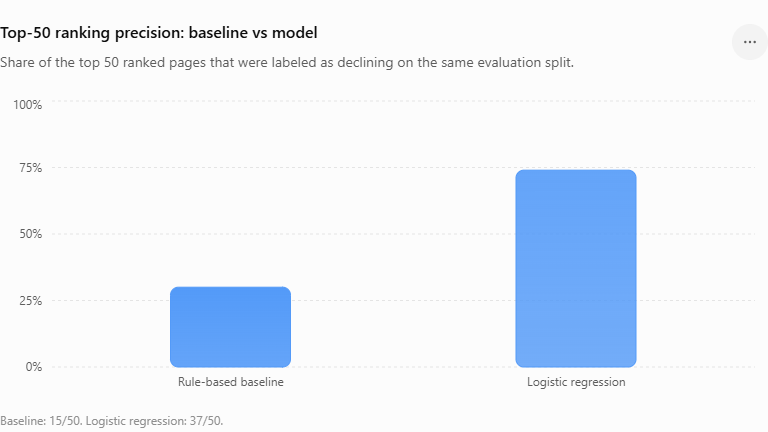

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

The results demonstrate that the learned model produced a stronger ranking than the hand-written baseline under the tested evaluation setup. They should not be interpreted as proof that the model will produce the same results in production or that the identified signals cause content decline.

### 5.1 Dataset scope

The reported modeling results were produced using the **30,000-row anonymized content-refresh dataset**. Although the broader FlyRank warehouse provided the data context and was used during the earlier data-contract and baseline stages, the reported Week 5–7 model was not trained across the full warehouse.

The results should therefore not be generalized automatically to the entire FlyRank production population.

### 5.2 Label limitation

The target was derived from `trend_direction`. Therefore, the model learns to identify pages associated with the dataset's definition of a downward trend.

A high predicted decline score does not independently establish that a page is objectively underperforming, nor does it explain why the decline occurred.

### 5.3 Association is not causation

The model identifies statistical patterns associated with the declining label. It does not establish that changing any individual feature will prevent a decline.

For example, a relationship between content freshness and decline risk should not be interpreted as proof that updating a page will necessarily recover its performance.

### 5.4 Validation scope

The evaluation used a client-grouped train/test split with **25 training clients and 7 previously unseen test clients**. This provides a stronger test of client-level generalization than a random page-level split, but it is still a single holdout split.

The reported Precision@50 should therefore be treated as an observed result for this evaluation setup rather than as a guaranteed future performance level.

### 5.5 Model and feature limitations

The final supervised model used 27 engineered features and logistic regression. Other model families, additional feature engineering, temporal validation strategies, and hyperparameter configurations could produce different results.

The analysis therefore demonstrates the usefulness of the tested approach rather than establishing that logistic regression is the optimal model for every future version of the problem.

### 5.6 Ranking limitations

Precision@50 measures how many labeled declining pages appear near the top of the ranking. It does not measure the business value of acting on those pages.

A page can be correctly ranked as declining while still being a poor candidate for a refresh because of factors not represented in the dataset, such as strategic importance, editorial priorities, seasonality, technical issues, or planned content changes.

### 5.7 Reason-code limitations

The human-readable reason codes in the ranked queue are rule-based review signals. They are intended to help reviewers understand observable conditions associated with a page.

They should not be interpreted as explanations of the internal logistic-regression prediction or as causal diagnoses of decline.

### 5.8 Distribution and time limitations

Search behavior, client populations, content strategies, and performance distributions can change over time. New clients or previously unseen content types may also differ from the data used for training.

For this reason, the model should be monitored after deployment and re-evaluated when performance, feature distributions, or the underlying population changes materially.

### 5.9 Operational limitation

The system is designed as **decision support**.

A high-risk page should receive attention sooner; it should not automatically be refreshed, rewritten, redirected, or removed. Final actions require human review of the page, its business context, search intent, current performance, and any information unavailable to the model.

### Honest conclusion

Within the tested dataset and client-grouped evaluation setup, the model produced a substantially stronger top-50 ranking than the rule-based baseline. The evidence supports using the model as a **prioritization aid for human review**, but it does not justify claims of guaranteed future performance, causal explanations, or fully automated content decisions.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked Recommendations

The model's primary operational output is a ranked review queue. Pages are ordered by their estimated probability of belonging to the declining class, allowing a content or SEO team to focus limited review capacity on the pages most likely to require attention.

The ranking is intended to support prioritization rather than automate the final content decision.

### 6.1 Recommended review order

**1. Review high-risk pages first**

Pages receiving the highest decline-risk scores should be reviewed first because the model places them at the top of the predicted-decline ranking.

The Week 7 queue combines the model score with human-readable review signals such as low CTR, stale content, lower search position, older content, and low engagement.

**2. Prioritize high-risk pages that are also stale**

A page with both high model decline risk and a long period since its last update should receive particular attention.

These pages are candidates for a content-refresh review, but the reviewer should first confirm that the page still matches the intended search intent and that updating it is strategically appropriate.

**3. Investigate low CTR before changing content**

When a high-risk page also has low CTR, reviewers should examine the search-result presentation and page targeting before deciding on a refresh.

Potential review areas include title and description alignment, search intent, content relevance, and whether the page is competing for the appropriate queries.

**4. Investigate search-position and engagement signals**

Pages with high decline risk and weaker search position or engagement should be reviewed for possible content-quality, relevance, or user-experience issues.

These signals are indicators for investigation rather than automatic diagnoses.

**5. Use lower-ranked pages as secondary work**

Pages with lower model scores should remain available in the queue but can be reviewed after the highest-priority pages, subject to team capacity and business priorities.

### 6.2 Human review before action

The ranked score should determine **review priority**, not the final action.

Before refreshing a page, a reviewer should consider:

- whether the page still satisfies its intended search intent;
- whether the topic remains strategically important;
- whether the observed decline is temporary or persistent;
- whether the page has recently undergone another change;
- whether technical or external factors could explain the performance;
- whether updating the content is likely to be more valuable than other available work.

A page should therefore move from **model priority → human review → final action**, rather than directly from **model priority → automated refresh**.

### 6.3 Recommended action categories

The Week 7 queue uses three broad action outcomes:

| Priority condition | Recommended review |
|---|---|
| High decline risk + substantial staleness | **Review for refresh** |
| High decline risk without substantial staleness | **High-priority review** |
| Lower decline risk | **Review if capacity allows** |

These categories provide a simple operational interpretation of the ranked output while keeping the final decision with a human reviewer.

### 6.4 How the queue should be used

The queue should be treated as a **worklist**, not as a definitive diagnosis.

For example, a page near the top of the queue may be prioritized because its model score is high, while the accompanying reason codes identify observable conditions that are useful to inspect. The reviewer then determines whether those signals correspond to a genuine content opportunity.

This approach combines the model's ability to rank a large set of pages consistently with human judgment about context that is not represented in the dataset.

### 6.5 Recommended operating workflow

The proposed workflow is:

**Rank → Review → Diagnose → Decide → Act → Monitor**

1. **Rank** pages using the model's decline-risk score.
2. **Review** the highest-priority pages first.
3. **Diagnose** the likely source of the performance issue using available SEO and content evidence.
4. **Decide** whether a refresh or another intervention is appropriate.
5. **Act** only after human approval.
6. **Monitor** the affected pages and evaluate whether the recommendation remains useful over time.

The purpose of this workflow is to make the model useful without treating its predictions as automatic instructions.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the Paper Embeds

The deployed research page will embed a small set of artifacts selected to communicate the main findings clearly without overwhelming the reader.

### 7.1 Model vs baseline comparison

A bar chart will compare **Precision@50** for the rule-based baseline and logistic-regression model on the same held-out client split.

| Approach | Precision@50 | Actual declining pages in top 50 |
|---|---:|---:|
| Rule-based baseline | 30% | 15 / 50 |
| Logistic regression | 74% | 37 / 50 |

**Purpose:** Show the main result of the study: the learned model concentrated substantially more labeled declining pages in the highest-priority 50-page review queue.

### 7.2 Evaluation metrics table

The paper will include the logistic-regression evaluation metrics:

| Metric | Result |
|---|---:|
| Accuracy | 58.46% |
| Precision | 58.24% |
| Recall | 66.08% |
| Precision@50 | **74.00%** |

**Purpose:** Provide the numerical evaluation behind the headline finding and distinguish general classification performance from the ranking metric most relevant to the operational use case.

### 7.3 Ranked action queue

The paper will include a representative view of the Week 7 ranked action queue generated from the modeling workflow.

The queue contains:

- page identifier;
- client identifier;
- model/ranking score;
- model used;
- predicted decline probability;
- priority;
- recommended action;
- human-readable reason codes;
- relevant SEO and content signals.

The full queue is retained as a reproducible project artifact in the repository rather than displaying every row on the public research page.

**Purpose:** Demonstrate how the model output is translated from a prediction into a practical human-review workflow.

### 7.4 Reproducibility artifacts

The paper will link to the notebooks and repository used to produce the analysis, including the data investigation, modeling, evaluation, and ranked recommendation workflow.

The repository contains the supporting notebooks and generated artifacts required to inspect and reproduce the analysis subject to the dataset's access restrictions.

### Artifact selection principle

Only artifacts that directly support a finding or a reproducibility claim will be embedded in the paper. Charts will use clear labels and concise captions, and each visualization will have a short takeaway explaining what a reader should notice.

The public artifacts will contain only pseudonymized identifiers and derived results. Private client names, URLs, raw search queries, credentials, and other non-public information will not be included.

## 8. 5-Minute Demo Outline

### 1. Question — ~45 seconds

**Question:** Can observable content and SEO performance signals be used to prioritize pages labeled as declining for earlier human review?

The practical problem is that content teams may have more pages to review than they can inspect at once. The goal is therefore to identify which pages should receive attention first.

### 2. Method — ~1 minute

I compared a transparent hand-written ranking baseline with a logistic-regression model.

The model used **27 engineered features** derived from observable content and SEO signals. Evaluation used a **client-grouped train/test split**, with **25 clients for training and 7 previously unseen clients held out for evaluation**.

The main ranking metric was **Precision@50**, because the operational question is how many genuinely declining pages appear in the first 50 pages a reviewer would investigate.

### 3. One Chart — ~45 seconds

Show the **Baseline vs Logistic Regression Precision@50** chart.

- Baseline: **30% — 15 of the top 50 pages were labeled declining**
- Logistic regression: **74% — 37 of the top 50 pages were labeled declining**

The chart demonstrates the main difference in ranking quality under the tested evaluation setup.
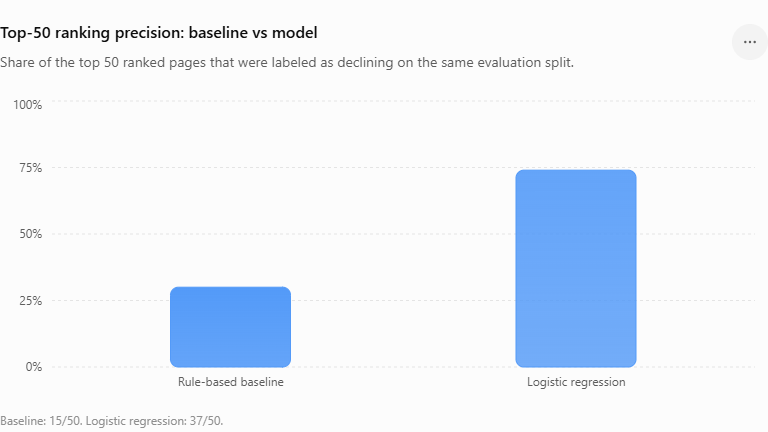






### 4. One Honest Result — ~1 minute

The logistic-regression model increased observed Precision@50 from **30% to 74%** on the held-out evaluation set.

This means that 37 of the model's top 50 ranked pages matched the declining label, compared with 15 of the baseline's top 50.

This is an observed evaluation result, not a guarantee of future production performance and not evidence that the model causes pages to recover.

### 5. One Recommendation — ~1 minute

Use the model as a **prioritization aid for human review**.

The recommended workflow is:

**Rank → Review → Diagnose → Decide → Act → Monitor**

High-risk pages should be reviewed first, with additional attention to observable signals such as staleness, low CTR, search position, and engagement. A human reviewer should confirm the context before deciding whether a refresh or another intervention is appropriate.

### Closing — ~30 seconds

The main takeaway is simple:

**The model does not decide what to change; it helps decide what deserves attention first.**

The project therefore demonstrates a practical decision-support workflow while keeping the final content decision with a human reviewer.

## 9. Shareable Cuts

### A. Short Social Post

I built a content-prioritization workflow during the FlyRank ML Internship to help identify pages that deserve earlier human review.

I compared a transparent rule-based baseline with a logistic-regression model using 27 engineered content and SEO performance features and a client-grouped evaluation setup. On the held-out evaluation set, Precision@50 increased from 30% for the baseline to 74% for the model, with 37 of the top 50 ranked pages matching the declining label compared with 15 under the baseline.

The key lesson was not to automate the content decision itself, but to build a ranking system that helps a reviewer decide where to look first.

### B. Employer-Facing Summary

I built a machine-learning content-prioritization workflow that compares a transparent rule-based baseline with logistic regression to rank pages for earlier human review. The work used a 30,000-row anonymized content-refresh dataset covering 32 pseudonymized clients, with 27 engineered content and SEO performance features and a client-grouped evaluation design. On the held-out evaluation set, the model achieved 74% Precision@50 compared with 30% for the baseline, showing stronger observed concentration of labeled declining pages in the highest-priority review queue.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.